In [24]:
# commpute wasserstain's distance (earth mover's distance) to quantify if there is significant drift

import pickle
import sqlite3
import numpy as np

# user inputs

model = "geosfp" #"merra2"
id_string = "inst3_3d_chm_Nv|CO2|1.0|Strat2" #"inst3_3d_asm_Nv|RH|22.0|Strat7"
year1, month1 = 2025, 1
year2, month2 = 2025, 2

# code

db_path = (
    f"/home/sadhika8/JupyterLinks/nobackup/quads_database/"
    f"{model}_monthly_aggregated_centroids_and_quantiles.db"
)

with sqlite3.connect(f"file:{db_path}?mode=ro", uri=True) as conn:

    def get(model, year, month, idstr):
        table = model

        row = conn.execute(
            f"""
            SELECT quantiles, quantile_list
            FROM {table}
            WHERE model = ? AND year = ? AND month = ? AND id_string = ?
            """,
            (model.upper(), year, month, idstr),
        ).fetchone()

        if row is None:
            return None

        return pickle.loads(row[0]), pickle.loads(row[1])

    a = get(model, year1, month1, id_string)
    b = get(model, year2, month2, id_string)


if a is None or b is None:
    print(
        f"Missing row: "
        f"{year1}-{month1:02d}={a is not None}, "
        f"{year2}-{month2:02d}={b is not None}"
    )
    raise SystemExit(1)



In [25]:
qa, qlist_a = a
qb, qlist_b = b

#print(f"Quantile lists identical: {qlist_a == qlist_b}")
#print(f"Unpickled quantiles equal: {qa == qb}")

#print(f"\n{year1}-{month1:02d}: {qa}")
#print(f"{year2}-{month2:02d}: {qb}")


wasserstein = np.trapezoid(
    np.abs(np.asarray(qa) - np.asarray(qb)),
    np.asarray(qlist_a),
)

mean_a = np.mean(qa)
std_a = np.std(qa)

mean_b = np.mean(qb)
std_b = np.std(qb)

normalized_wasserstein = wasserstein / mean_a

print(f"\n{year1}-{month1:02d}:")
print(f"  mean: {mean_a}")
print(f"  std:  {std_a}")

print(f"\n{year2}-{month2:02d}:")
print(f"  mean: {mean_b}")
print(f"  std:  {std_b}")

print(f"\nWasserstein distance:            {wasserstein}")
print(f"Mean Normalized Wasserstein distance: {normalized_wasserstein}")


2025-01:
  mean: 0.00042521439714802593
  std:  1.8929136859969364e-07

2025-02:
  mean: 0.0004254314815190421
  std:  1.3223737063607443e-07

Wasserstein distance:            2.3363750628866668e-07
Mean Normalized Wasserstein distance: 0.000549458127137056


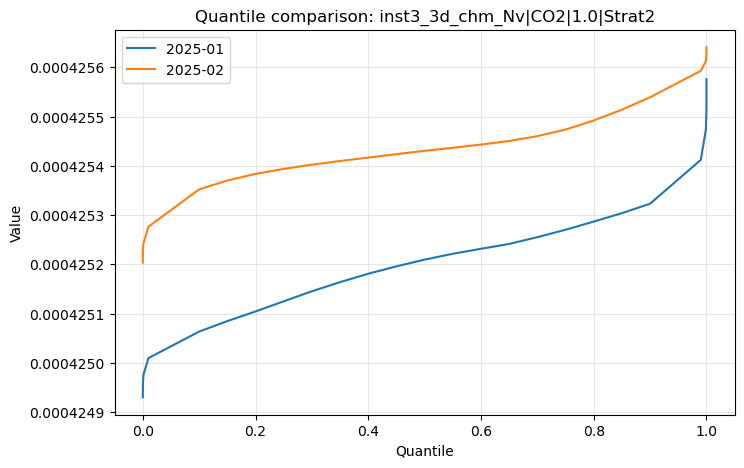

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(qlist_a, qa, label=f"{year1}-{month1:02d}")
plt.plot(qlist_b, qb, label=f"{year2}-{month2:02d}")

plt.xlabel("Quantile")
plt.ylabel("Value")
plt.title(f"Quantile comparison: {id_string}")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()